In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


<Axes: xlabel='cgpa', ylabel='resume_score'>

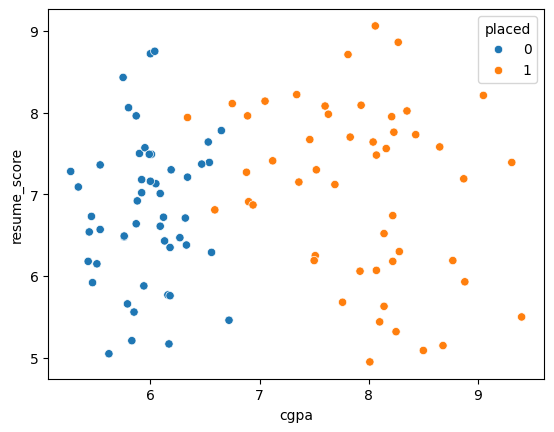

In [8]:
sns.scatterplot(x = df['cgpa'],y = df['resume_score'], hue= df['placed'] )

In [13]:
X = df.iloc[:,0:2]
Y = df.iloc[:,-1]

In [14]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [15]:
p.fit(X,Y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [16]:
p.coef_

array([[ 40.26, -36.  ]])

In [17]:
p.intercept_

array([-25.])

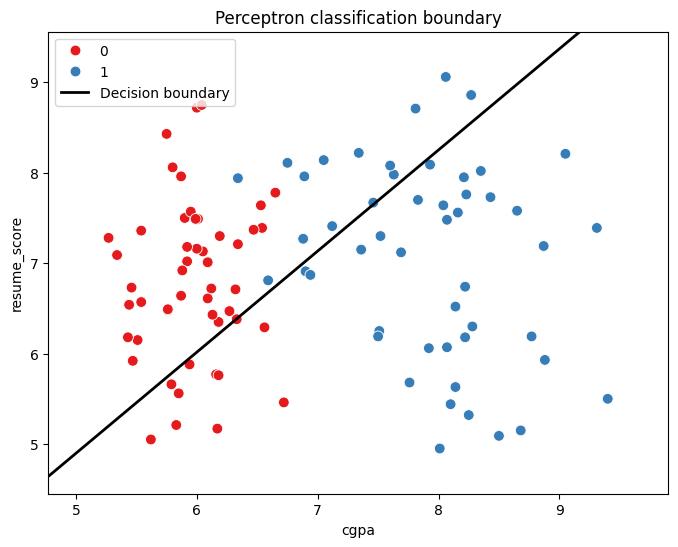

In [19]:
# plot scatter with decision boundary from the trained perceptron `p`
plt.figure(figsize=(8,6))
sns.scatterplot(x='cgpa', y='resume_score', hue='placed', data=df, palette='Set1', s=60)

w = p.coef_[0]
b = p.intercept_[0]

# handle near-vertical boundary (w[1] ~ 0)
if abs(w[1]) < 1e-8:
    x0 = -b / w[0]
    plt.axvline(x0, color='black', linewidth=2, label='Decision boundary')
else:
    x_vals = np.linspace(df['cgpa'].min() - 0.5, df['cgpa'].max() + 0.5, 200)
    y_vals = -(w[0] / w[1]) * x_vals - (b / w[1])
    plt.plot(x_vals, y_vals, color='black', linewidth=2, label='Decision boundary')

plt.xlabel('cgpa')
plt.ylabel('resume_score')
plt.title('Perceptron classification boundary')
plt.legend()
plt.xlim(df['cgpa'].min() - 0.5, df['cgpa'].max() + 0.5)
plt.ylim(df['resume_score'].min() - 0.5, df['resume_score'].max() + 0.5)
plt.show()

In [20]:
df1 = sns.load_dataset('iris')
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

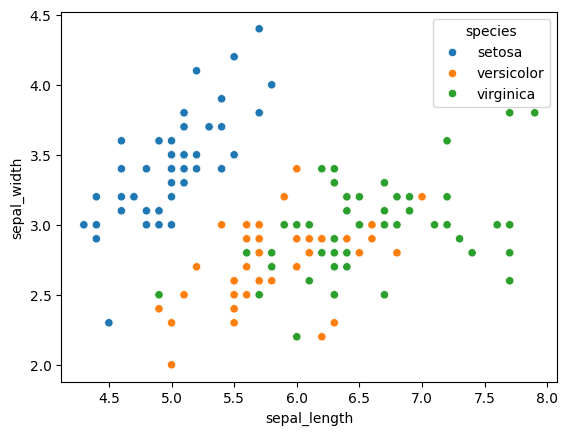

In [21]:
sns.scatterplot(x = df1['sepal_length'],y = df1['sepal_width'], hue= df1['species'] )

In [32]:
pp = Perceptron()
X1 = df1.iloc[:,0:2]
Y1 = df1.iloc[:,-1]
Y1 = Y1.map({'setosa':0, 'versicolor':1, 'virginica':2})
pp.fit(X1,Y1)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [33]:
pp.coef_   

array([[-33. ,  50.2],
       [ 13.8, -29.3],
       [ 17. , -34.3]])

In [34]:
pp.intercept_

array([ 13.,  15., -29.])

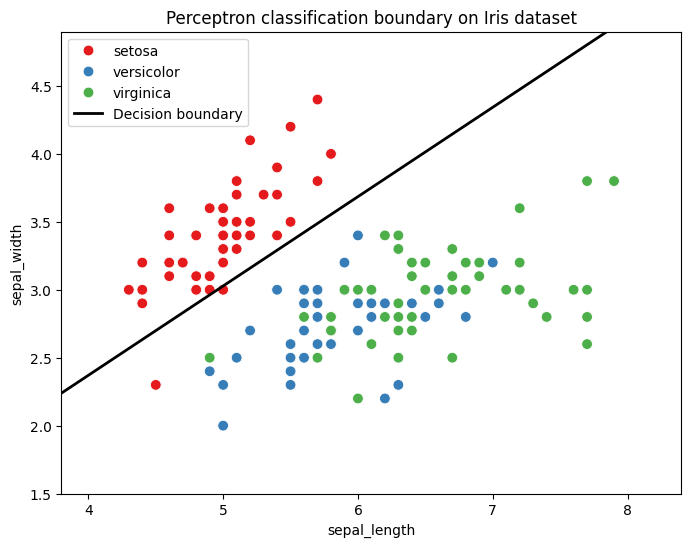

In [ ]:
# plot scatter with decision boundary from the trained perceptron `pp`
plt.figure(figsize=(8,6))
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df1, palette='Set1', s=60)
w1 = pp.coef_[0]
b1 = pp.intercept_[0]
# handle near-vertical boundary (w1[1] ~ 0)
if abs(w1[1]) < 1e-8:
    x0_1 = -b1 / w1[0]
    plt.axvline(x0_1, color='black', linewidth=2, label='Decision boundary')
else:
    
    x1_vals = np.linspace(df1['sepal_length'].min() - 0.5, df1['sepal_length'].max() + 0.5, 200)
    y1_vals = -(w1[0] / w1[1]) * x1_vals - (b1 / w1[1])
    plt.plot(x1_vals, y1_vals, color='black', linewidth=2, label='Decision boundary')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.title('Perceptron classification boundary on Iris dataset')
plt.legend()
plt.xlim(df1['sepal_length'].min() - 0.5, df1['sepal_length'].max() + 0.5)
plt.ylim(df1['sepal_width'].min() - 0.5, df1['sepal_width'].max() + 0.5)
plt.show()  